# Import Modules and Functions

In [3]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [5]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [8]:
## reference tables
table_a57 = pd.read_csv('LC_tables/data/LCref_a57_i.csv')
table_a54 = pd.read_csv('LC_tables/data/LCref_a54_i.csv')

## segment 1
lc_df1 = readin_LCdf('LC_tables/data/LCtable1_i.csv')

## segment 2
lc_df2 = readin_LCdf('LC_tables/data/LCtable2_i.csv')

## segment 3
lc_df3 = readin_LCdf('LC_tables/data/LCtable3_i.csv')

## segment 4
lc_df4 = readin_LCdf('LC_tables/data/LCtable4_i.csv')

In [10]:
### Some images need to be excluded due to quality
### Images from ccd 54 have bad bands (mainly filter i is affected)

badims_a54i = pd.read_csv('txt_files/ec0915a54i_badims.txt', header=None)[0]
bad_expnums_a54i = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54i]
# bad_expnums_a54i = None

In [12]:
### Read in iteration 1 LC model
LCmodel1 = pd.read_csv('LC_tables/models/iLC_m1.csv')

# Combine LCs

### Fitting Process for Each Segment

In [15]:
# ### Define uncertainty/error cut on flux error -- exclude outliers from fitting

f_lim = 20.0              # upper limit of flux (mJyas2)
ferr_lim = 1.0            # upper limit of flux error (mJyas2_err)

# ### The working indices for fitting process -- run before the rest
bin_sz = None
flag_inds(lc_df1, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=None, bin_size=bin_sz)
flag_inds(lc_df2, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)
flag_inds(lc_df3, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)
flag_inds(lc_df4, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i, bin_size=bin_sz)

'Updated LC dataframe -- flagged working indices'

In [17]:
### Fit LCs to a template
### 2nd iteration --> template is the model LC

## segment 1
fit_parms1 = fit_LCs(lc_df1, LCmodel=LCmodel1, metric=1e4)

## segment 2
fit_parms2 = fit_LCs(lc_df2, LCmodel=LCmodel1, metric=1e4)

## segment 3
    # define t_peaks -- easier to fit to model this way
    # last entry of t_peaks list should be of the template
seg3_inds = [np.where((lc_df3.t['ID'].eq(i)) & (lc_df3.t['g_ixs_flag'].eq(True)))[0] for i in np.unique(lc_df3.t['ID'])]
tpeaks3 = [find_t_peak(lc_df3.t.loc[seg3_inds[i],'mjd'],lc_df3.t.loc[seg3_inds[i],'mJyas2'],lc_df3.t.loc[seg3_inds[i],'mJyas2_err'], metric=1e4, t_range=[57000,57900]) for i in range(len(seg3_inds))]
m_tpeak = find_t_peak(LCmodel1['mjd'].values,LCmodel1['mJyas2'].values,LCmodel1['mJyas2_err'].values, metric=None, t_range=[59000,60000])
tp_lst3 = list(tpeaks3) + list([m_tpeak])

fit_parms3 = fit_LCs(lc_df3, LCmodel=LCmodel1, metric=None, t_peaks=tp_lst3)

## segment 4
    # no tshift as the tail end seems aligned -- also no specific feature to pinpoint
    # just fit to end of model
tpeaks4 = 'ends'
fit_parms4 = fit_LCs(lc_df4, LCmodel=LCmodel1, metric=None, t_peaks=tpeaks4)

In [19]:
### Save tshifts for other filters

i2parms1 = pd.DataFrame(fit_parms1)
i2parms2 = pd.DataFrame(fit_parms2)
i2parms3 = pd.DataFrame(fit_parms3)
i2parms4 = pd.DataFrame(fit_parms4)


i2parms1.to_csv('LC_tables/fit_params/f2params_i1.csv', index=False)
i2parms2.to_csv('LC_tables/fit_params/f2params_i2.csv', index=False)
i2parms3.to_csv('LC_tables/fit_params/f2params_i3.csv', index=False)
i2parms4.to_csv('LC_tables/fit_params/f2params_i4.csv', index=False)

In [21]:
### Create data frame of aligned and combined LCs

## segment 1
comb1 = get_combLCs(lc_df1, fit_parms1, LCmodel=LCmodel1)

## segment 2
comb2 = get_combLCs(lc_df2, fit_parms2, LCmodel=LCmodel1)

## segment 3
comb3 = get_combLCs(lc_df3, fit_parms3, LCmodel=LCmodel1)

## segment 4
comb4 = get_combLCs(lc_df4, fit_parms4, LCmodel=LCmodel1)

In [23]:
### Get LC curve fit

## segment 1
c_t1, c_mu1, c_std1 = get_LCfit(comb1, metric=5e4)

## segment 2
c_t2, c_mu2, c_std2 = get_LCfit(comb2, metric=5e4)

## segment 3
c_t3, c_mu3, c_std3 = get_LCfit(comb3, metric=5e4)

## segment 4
c_t4, c_mu4, c_std4 = get_LCfit(comb4, metric=5e4)

### See/Check Fitting Process

In [16]:
### See individual LCs

## 4 segments (labelled 1-4)

# plot_lcs(lc_df3)
# plot_lcs(lc_df3, plot_orig=True)
# plot_lcs(lc_df1, plt_xl=60400)

In [17]:
### Check how peaks are found

# ch_df = lc_df4
# lc_ids = np.unique(ch_df.t['ID'])
# for i in lc_ids: 
#     check_inds = np.where(ch_df.t['ID'].eq(i) & ch_df.t['g_ixs_flag'].eq(True))[0]
#     ch_t, ch_mu, ch_std = get_LCfit(ch_df,indices=check_inds, metric=1e4)

#     plt.scatter(ch_df.t.loc[check_inds,'mjd'], ch_df.t.loc[check_inds,'mJyas2'])
#     plt.scatter(ch_t,ch_mu)

#     # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57000,57900])
#     # plt.axvline(tpeak)
    
#     plt.show()

In [18]:
### See Fitting Process

# df = lc_df4
# fit_ps = fit_parms4

# plot_LCfits(df,fit_ps, LCmodel=LCmodel1)

In [19]:
### See comb LCs

# df = lc_df1
# fit_ps = fit_parms1
# t_ID = templ_ID1

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i)
#     plt.errorbar(df.t.loc[df_inds,'new_mjd'], df.t.loc[df_inds,'new_mJyas2'], yerr=df.t.loc[df_inds,'new_mJyas2_err'], fmt='.-', ecolor='black')

In [20]:
### See combined LC

# c_df = comb4
# t_mns = c_t4
# f_mns = c_mu4
# f_mers = c_std4

# plt.errorbar(c_df.t['mjd'], c_df.t['mJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(t_mns, f_mns, fmt='--.', ecolor='black', color='orange') #,yerr=f_mers

# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# plt.show()

# Model LC

### Combine Segments

In [25]:
### Combine Segments
    ## Model data already connected in iteration 2
    ## Combine LC data

tls_m = np.concatenate([comb1.t['mjd'].values, comb2.t['mjd'].values, comb3.t['mjd'].values, comb4.t['mjd'].values])
fls_m = np.concatenate([comb1.t['mJyas2'].values, comb2.t['mJyas2'].values, comb3.t['mJyas2'].values, comb4.t['mJyas2'].values])
ferrls_m = np.concatenate([comb1.t['mJyas2_err'].values, comb2.t['mJyas2_err'].values, comb3.t['mJyas2_err'].values, comb4.t['mJyas2_err'].values])

ord_inds_m = tls_m.argsort()
tls_m = tls_m[ord_inds_m]
fls_m = fls_m[ord_inds_m]
ferrls_m = ferrls_m[ord_inds_m]

comb_m_data = {'mjd': tls_m, 'mJyas2': fls_m, 'mJyas2_err': ferrls_m}
comb_m = pdastrostatsclass()
comb_m.t = comb_m.t.assign(**comb_m_data)

In [41]:
### Create the model (LC_0)

m_t, m_mu, m_std = get_LCfit(comb_m, metric=3e4)

main_peak = m_t[np.where(m_mu==max(m_mu))[0][0]]

### Save main peak loc for other filters
mpeak_i = {'mpeak': [main_peak]}
mpeak_tab = pd.DataFrame(mpeak_i)
mpeak_tab.to_csv('LC_tables/fit_params/mpeak_i.csv', index=False)

phase_m = m_t - main_peak

lc_model = {'mjd':m_t, 'mJyas2':m_mu, 'mJyas2_err':m_std, 'phase':phase_m}
lc_model_d = pd.DataFrame(lc_model)

lc_model_d.to_csv('LC_tables/models/iLC_m2.csv', index=False)


comb_m.t['phase'] = comb_m.t['mjd'] - main_peak

## Save table for bookkeeping purposes
comb_m.t.to_csv('LC_tables/models/iLC_data2.csv', index=False)

### See Model Fitting

In [30]:
### Individual Segements

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD (days)')

# axs[0].errorbar(c_t1, c_mu1, yerr=c_std1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# axs[1].errorbar(c_t2, c_mu2, yerr=c_std2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# axs[2].errorbar(c_t3, c_mu3, yerr=c_std3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# axs[3].errorbar(c_t4, c_mu4, yerr=c_std4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
#     ax.legend(fontsize = 14)


# # axs[1].axvline(find_t_peak(c_t2,c_mu2,c_std2, metric=None, t_range=[59000,60000]))
# # axs[2].axvline(find_t_peak(c_t3,c_mu3,c_std3, metric=None, t_range=[57000,57800]))

# # pl_fig.savefig('../figures/display/EtaCar_PiecesM.png', bbox_inches = 'tight', dpi=100)

In [31]:
### See Connected Segments

# fig, ax = plt.subplots(dpi = 100, figsize = [8,5])
# ax.minorticks_on()
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
# ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# ax.set_xlabel('MJD (days)', fontsize = 14)
# ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
# ax.ticklabel_format(axis='both', style='plain')


# ax.errorbar(c_t1, c_mu1, yerr=c_std1, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
# ax.errorbar(c_t2, c_mu2, yerr=c_std2, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
# ax.errorbar(c_t3, c_mu3, yerr=c_std3, fmt='--.', ecolor='black', color='red', label='Loc 3')
# ax.errorbar(c_t4, c_mu4, yerr=c_std4, fmt='--.', ecolor='black', color='orange', label='Loc 4')

# ax.axhline(y=0, ls='--', color='k')

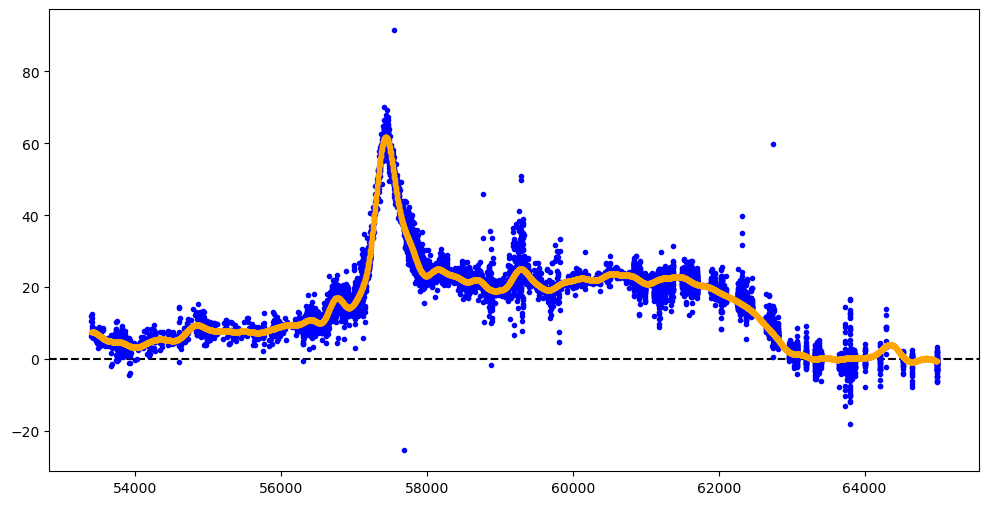

In [32]:
### Plot Model

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_m.t['mjd'], comb_m.t['mJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_t, m_mu, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')